# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [37]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [38]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [39]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [40]:
df_median_household_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_people_below_poverty_level = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_over_25_completed_highschool = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_by_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_deaths_by_police = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [41]:
print(f"Shape of Median Household Income data: {df_median_household_income.shape}")
print(f"Shape of Percentage People Below Poverty Level data: {df_pct_people_below_poverty_level.shape}")
print(f"Shape of Percentage Over 25 Completed Highschool data: {df_pct_over_25_completed_highschool.shape}")
print(f"Shape of Share of Race by City data: {df_share_race_by_city.shape}")
print(f"Shape of Deaths caused by Police in US data: {df_deaths_by_police.shape}")

Shape of Median Household Income data: (29322, 3)
Shape of Percentage People Below Poverty Level data: (29329, 3)
Shape of Percentage Over 25 Completed Highschool data: (29329, 3)
Shape of Share of Race by City data: (29268, 7)
Shape of Deaths caused by Police in US data: (2535, 14)


In [42]:
print(f"Shape of Median Household Income data:\nRows: {df_median_household_income.shape[0]} Columns: {df_median_household_income.shape[1]}")
print(f"Shape of Percentage People Below Poverty Level data:\nRows: {df_pct_people_below_poverty_level.shape[0]} Columns: {df_pct_people_below_poverty_level.shape[1]}")
print(f"Shape of Percentage Over 25 Completed Highschool data:\nRows: {df_pct_over_25_completed_highschool.shape[0]} Columns: {df_pct_over_25_completed_highschool.shape[1]}")
print(f"Shape of Share of Race by City data:\nRows: {df_share_race_by_city.shape[0]} Columns: {df_share_race_by_city.shape[1]}")
print(f"Shape of Deaths caused by Police in US data:\nRows: {df_deaths_by_police.shape[0]} Columns: {df_deaths_by_police.shape[1]}")

Shape of Median Household Income data:
Rows: 29322 Columns: 3
Shape of Percentage People Below Poverty Level data:
Rows: 29329 Columns: 3
Shape of Percentage Over 25 Completed Highschool data:
Rows: 29329 Columns: 3
Shape of Share of Race by City data:
Rows: 29268 Columns: 7
Shape of Deaths caused by Police in US data:
Rows: 2535 Columns: 14


In [43]:
print(f"Shape of Median Household Income column names: {df_median_household_income.columns}")
print(f"Shape of Percentage People Below Poverty Level column names: {df_pct_people_below_poverty_level.columns}")
print(f"Shape of Percentage Over 25 Completed Highschool column names: {df_pct_over_25_completed_highschool.columns}")
print(f"Shape of Share of Race by City column names: {df_share_race_by_city.columns}")
print(f"Shape of Deaths caused by Police in US column names: {df_deaths_by_police.columns}")

Shape of Median Household Income column names: Index(['Geographic Area', 'City', 'Median Income'], dtype='str')
Shape of Percentage People Below Poverty Level column names: Index(['Geographic Area', 'City', 'poverty_rate'], dtype='str')
Shape of Percentage Over 25 Completed Highschool column names: Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='str')
Shape of Share of Race by City column names: Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='str')
Shape of Deaths caused by Police in US column names: Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='str')


In [44]:
print(f"Median Household Income NaN values:\n{df_median_household_income.isnull().sum()}")
print(f"\nPercentage People Below Poverty Level NaN values:\n{df_pct_people_below_poverty_level.isnull().sum()}")
print(f"\nPercentage Over 25 Completed Highschool NaN values:\n{df_pct_over_25_completed_highschool.isnull().sum()}")
print(f"\nShare of Race by City NaN values:\n{df_share_race_by_city.isnull().sum()}")
print(f"\nDeaths caused by Police in US NaN values:\n{df_deaths_by_police.isnull().sum()}")

Median Household Income NaN values:
Geographic Area     0
City                0
Median Income      51
dtype: int64

Percentage People Below Poverty Level NaN values:
Geographic Area    0
City               0
poverty_rate       0
dtype: int64

Percentage Over 25 Completed Highschool NaN values:
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64

Share of Race by City NaN values:
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64

Deaths caused by Police in US NaN values:
id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness 

In [45]:
print(df_median_household_income.duplicated().sum())
print(df_pct_people_below_poverty_level.duplicated().sum())
print(df_pct_over_25_completed_highschool.duplicated().sum())
print(df_share_race_by_city.duplicated().sum())
print(df_deaths_by_police.duplicated().sum())

0
0
0
0
0


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [46]:
datasets = [df_median_household_income, df_pct_people_below_poverty_level, df_pct_over_25_completed_highschool, df_share_race_by_city, df_deaths_by_police]

def swap_nans_with_zero():
    for data in datasets:
        for col in data.columns:
            if data[col].dtype == 'object' or hasattr(data[col], 'str'):
                data[col] = data[col].fillna('Unknown')
            else:
                data[col] = data[col].fillna(0)

swap_nans_with_zero()


In [47]:
print(f"Median Household Income NaN values:\n{df_median_household_income.isnull().sum()}")
print(f"\nPercentage People Below Poverty Level NaN values:\n{df_pct_people_below_poverty_level.isnull().sum()}")
print(f"\nPercentage Over 25 Completed Highschool NaN values:\n{df_pct_over_25_completed_highschool.isnull().sum()}")
print(f"\nShare of Race by City NaN values:\n{df_share_race_by_city.isnull().sum()}")
print(f"\nDeaths caused by Police in US NaN values:\n{df_deaths_by_police.isnull().sum()}")

Median Household Income NaN values:
Geographic Area    0
City               0
Median Income      0
dtype: int64

Percentage People Below Poverty Level NaN values:
Geographic Area    0
City               0
poverty_rate       0
dtype: int64

Percentage Over 25 Completed Highschool NaN values:
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64

Share of Race by City NaN values:
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64

Deaths caused by Police in US NaN values:
id                         0
name                       0
date                       0
manner_of_death            0
armed                      0
age                        0
gender                     0
race                       0
city                       0
state                      0
signs_of_mental_illness    0
threat_level      

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [48]:
state_abbreviations = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia'
}

# Fix poverty_rate dtype first
df_pct_people_below_poverty_level['poverty_rate'] = pd.to_numeric(
    df_pct_people_below_poverty_level['poverty_rate'], errors='coerce'
).fillna(0)

# Now groupby will work
df_poverty_by_state = df_pct_people_below_poverty_level.groupby('Geographic Area')['poverty_rate'].mean().reset_index()
df_poverty_by_state.columns = ['state', 'avg_poverty_rate']
df_poverty_by_state = df_poverty_by_state.sort_values('avg_poverty_rate', ascending=True)

df_poverty_by_state['state'] = df_poverty_by_state['state'].map(state_abbreviations)
df_poverty_by_state = df_poverty_by_state.dropna(subset=['state'])

print(df_poverty_by_state)


                   state  avg_poverty_rate
31            New Jersey              8.16
50               Wyoming              9.06
6            Connecticut              9.14
19         Massachusetts              9.55
20              Maryland             10.27
39          Rhode Island             10.37
34              New York             11.64
44                  Utah             11.72
28          North Dakota             12.13
12                  Iowa             12.23
33                Nevada             12.37
38          Pennsylvania             12.49
8               Delaware             12.56
30         New Hampshire             12.66
48             Wisconsin             12.86
29              Nebraska             12.92
5               Colorado             13.19
11                Hawaii             13.40
23             Minnesota             13.75
46               Vermont             13.79
14              Illinois             13.85
45              Virginia             14.59
16         

Index(['Geographic Area', 'City', 'poverty_rate'], dtype='str')


/tmp/ipykernel_18583/401637108.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


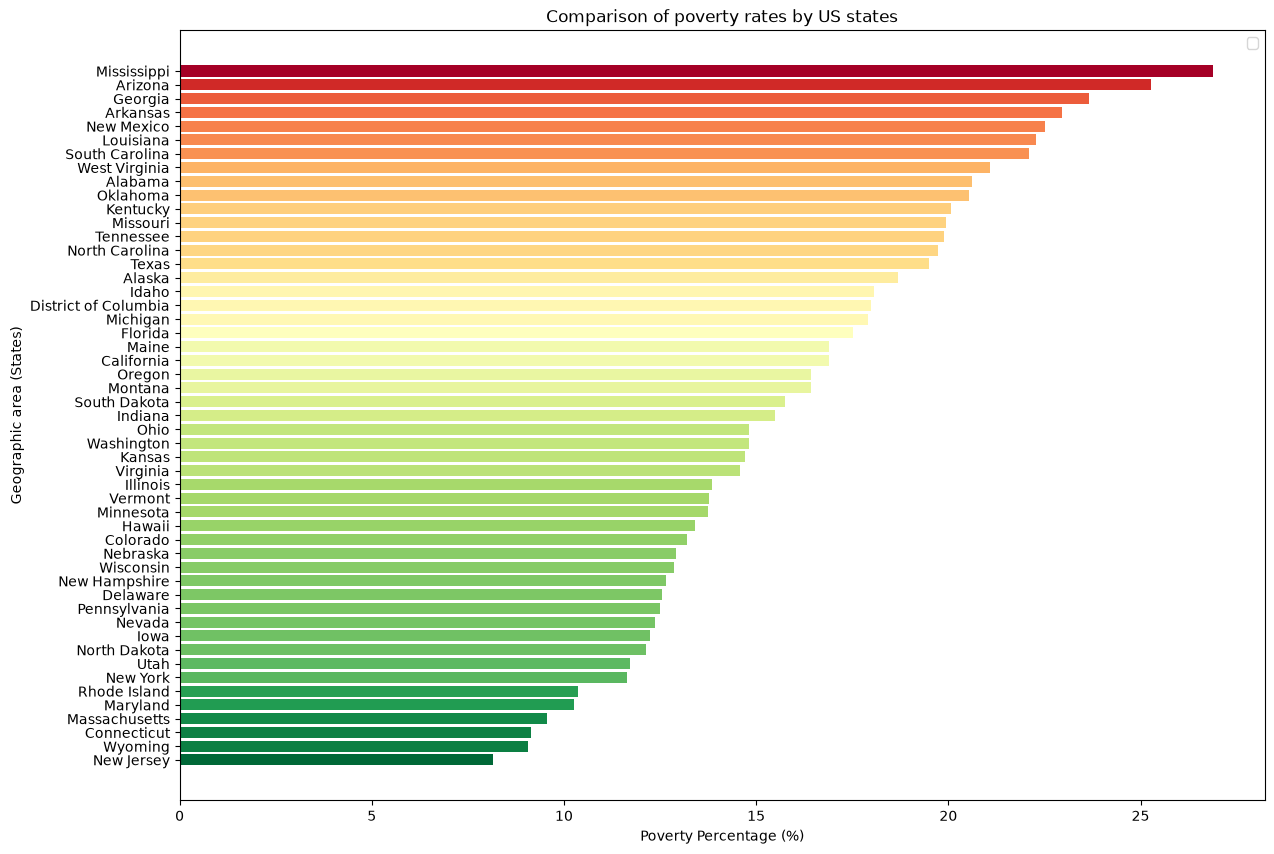

In [49]:
import matplotlib.colors as mcolors

print(df_pct_people_below_poverty_level.columns)

norm = mcolors.Normalize(vmin=df_poverty_by_state['avg_poverty_rate'].min(), vmax=df_poverty_by_state['avg_poverty_rate'].max())
colors = plt.cm.RdYlGn_r(norm(df_poverty_by_state['avg_poverty_rate']))

# bar chart
plt.figure(figsize=[14, 10])
plt.barh(df_poverty_by_state['state'], df_poverty_by_state['avg_poverty_rate'], color=colors)
plt.legend()
plt.xlabel('Poverty Percentage (%)')
plt.ylabel('Geographic area (States)')
plt.title('Comparison of poverty rates by US states')
plt.show()

In [50]:
import plotly.io as pio
print(pio.renderers)

Renderers configuration
-----------------------
    Default renderer: 'browser'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [51]:
import plotly.express as px

# Group by state for choropleth
df_poverty_map = df_pct_people_below_poverty_level.groupby('Geographic Area')['poverty_rate'].mean().reset_index()
df_poverty_map.columns = ['state', 'avg_poverty_rate']

fig = px.choropleth(
    df_poverty_map,
    locations='state',
    locationmode='USA-states',
    color='avg_poverty_rate',
    scope='usa',
    color_continuous_scale='RdYlGn_r',
    title='Average Poverty Rate by US State',
    labels={'avg_poverty_rate': 'Avg Poverty Rate (%)'}
)

fig.update_layout(
    geo=dict(showlakes=True, lakecolor='LightBlue'),
    title_x=0.5
)

fig.show()

In [52]:
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'browser'

# Load free US cities dataset with lat/lon
us_cities_url = "https://raw.githubusercontent.com/kelvins/US-Cities-Database/main/csv/us_cities.csv"
df_us_cities = pd.read_csv(us_cities_url)
print(df_us_cities.columns)
print(df_us_cities.head())
print(df_us_cities.shape)

Index(['ID', 'STATE_CODE', 'STATE_NAME', 'CITY', 'COUNTY', 'LATITUDE',
       'LONGITUDE'],
      dtype='str')
   ID STATE_CODE STATE_NAME      CITY          COUNTY  LATITUDE  LONGITUDE
0   1         AK     Alaska      Adak  Aleutians West     56.00    -161.21
1   2         AK     Alaska  Akiachak          Bethel     60.89    -161.39
2   3         AK     Alaska     Akiak          Bethel     60.89    -161.20
3   4         AK     Alaska    Akutan  Aleutians East     54.14    -165.79
4   5         AK     Alaska  Alakanuk        Kusilvak     62.75    -164.60
(29880, 7)


In [53]:
# Check what the city names look like in each dataset
print("Poverty dataset sample:")
print(df_pct_people_below_poverty_level[['City', 'Geographic Area']].head(10))

print("\nUS Cities dataset sample:")
print(df_us_cities[['CITY', 'STATE_CODE']].head(10))

# Check for mismatches - cities in poverty data not found in us_cities
poverty_cities = set(zip(df_pct_people_below_poverty_level['City'], df_pct_people_below_poverty_level['Geographic Area']))
us_cities = set(zip(df_us_cities['CITY'], df_us_cities['STATE_CODE']))

unmatched = poverty_cities - us_cities
print(f"\nUnmatched cities: {len(unmatched)}")
print("\nSample of unmatched:")
for city, state in list(unmatched)[:20]:
    print(f"  '{city}', '{state}'")

Poverty dataset sample:
                  City Geographic Area
0           Abanda CDP              AL
1       Abbeville city              AL
2      Adamsville city              AL
3         Addison town              AL
4           Akron town              AL
5       Alabaster city              AL
6     Albertville city              AL
7  Alexander City city              AL
8       Alexandria CDP              AL
9      Aliceville city              AL

US Cities dataset sample:
             CITY STATE_CODE
0            Adak         AK
1        Akiachak         AK
2           Akiak         AK
3          Akutan         AK
4        Alakanuk         AK
5       Aleknagik         AK
6       Allakaket         AK
7          Ambler         AK
8  Anaktuvuk Pass         AK
9    Anchor Point         AK

Unmatched cities: 29327

Sample of unmatched:
  'Prentice village', 'WI'
  'Tipton city', 'IA'
  'Wasta town', 'SD'
  'Free Union CDP', 'VA'
  'Onaga city', 'KS'
  'Moss Point city', 'MS'
  'Warner Ro

In [54]:
# Remove suffixes from city names
import re

suffixes = r'\s+(city|town|village|CDP|borough|township|municipality|urban district|metro government|consolidated government|unified government)$'

df_pct_people_below_poverty_level['City_clean'] = (
    df_pct_people_below_poverty_level['City']
    .str.strip()
    .str.replace(suffixes, '', flags=re.IGNORECASE, regex=True)
    .str.strip()
)

# Verify
print(df_pct_people_below_poverty_level[['City', 'City_clean']].head(20))

                   City      City_clean
0            Abanda CDP          Abanda
1        Abbeville city       Abbeville
2       Adamsville city      Adamsville
3          Addison town         Addison
4            Akron town           Akron
5        Alabaster city       Alabaster
6      Albertville city     Albertville
7   Alexander City city  Alexander City
8        Alexandria CDP      Alexandria
9       Aliceville city      Aliceville
10         Allgood town         Allgood
11         Altoona town         Altoona
12       Andalusia city       Andalusia
13        Anderson town        Anderson
14        Anniston city        Anniston
15            Arab city            Arab
16         Ardmore town         Ardmore
17            Argo town            Argo
18          Ariton town          Ariton
19           Arley town           Arley


In [55]:
# See what City_clean actually looks like
print(df_pct_people_below_poverty_level[['City', 'City_clean']].head(20))

# See a sample of your cities dataset
print(df_us_cities['CITY'].head(20))

# Find near-misses — cities that are close but not matching
from difflib import get_close_matches

poverty_cities = df_pct_people_below_poverty_level['City_clean'].dropna().unique()
us_cities = df_us_cities['CITY'].unique()

for city in poverty_cities[:20]:
    matches = get_close_matches(city, us_cities, n=1, cutoff=0.8)
    if not matches:
        print(f"No match for: '{city}'")

                   City      City_clean
0            Abanda CDP          Abanda
1        Abbeville city       Abbeville
2       Adamsville city      Adamsville
3          Addison town         Addison
4            Akron town           Akron
5        Alabaster city       Alabaster
6      Albertville city     Albertville
7   Alexander City city  Alexander City
8        Alexandria CDP      Alexandria
9       Aliceville city      Aliceville
10         Allgood town         Allgood
11         Altoona town         Altoona
12       Andalusia city       Andalusia
13        Anderson town        Anderson
14        Anniston city        Anniston
15            Arab city            Arab
16         Ardmore town         Ardmore
17            Argo town            Argo
18          Ariton town          Ariton
19           Arley town           Arley
0               Adak
1           Akiachak
2              Akiak
3             Akutan
4           Alakanuk
5          Aleknagik
6          Allakaket
7            

In [56]:
df_city_poverty = df_pct_people_below_poverty_level.merge(
    df_us_cities[['CITY', 'STATE_CODE', 'LATITUDE', 'LONGITUDE']],
    left_on=['City_clean', 'Geographic Area'],
    right_on=['CITY', 'STATE_CODE'],
    how='inner'
)

print(df_city_poverty.head())

df_city_poverty = df_city_poverty.sort_values('poverty_rate', ascending=True).reset_index(drop=True)

print(df_city_poverty.head())

print(f"Matched {len(df_city_poverty)} cities")

df_city_poverty_filtered = df_city_poverty[df_city_poverty['poverty_rate'] > 10]
print(f"Cities with poverty rate above 10%: {len(df_city_poverty_filtered)}")

  Geographic Area             City  poverty_rate  City_clean        CITY  \
0              AL   Abbeville city         29.10   Abbeville   Abbeville   
1              AL  Adamsville city         25.50  Adamsville  Adamsville   
2              AL     Addison town         30.70     Addison     Addison   
3              AL       Akron town         42.00       Akron       Akron   
4              AL   Alabaster city         11.20   Alabaster   Alabaster   

  STATE_CODE  LATITUDE  LONGITUDE  
0         AL     31.58     -85.28  
1         AL     33.59     -86.96  
2         AL     34.21     -87.19  
3         AL     32.87     -87.71  
4         AL     33.24     -86.81  
  Geographic Area                City  poverty_rate  City_clean        CITY  \
0              ND      Pillsbury city          0.00   Pillsbury   Pillsbury   
1              CA      Farmington CDP          0.00  Farmington  Farmington   
2              CA       Fish Camp CDP          0.00   Fish Camp   Fish Camp   
3          

In [57]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'browser'

fig = px.scatter_mapbox(
    df_city_poverty_filtered,
    lat='LATITUDE',
    lon='LONGITUDE',
    color='poverty_rate',
    size='poverty_rate',
    hover_name='City',
    hover_data={'poverty_rate': True, 'Geographic Area': True},
    color_continuous_scale='RdYlGn_r',
    size_max=20,
    zoom=3,
    title='Poverty Rate by City across the US',
    labels={'poverty_rate': 'Poverty Rate (%)'}
)

fig.update_layout(
    mapbox_style='open-street-map',  # free, no API key needed
    title_x=0.5,
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

/tmp/ipykernel_18583/685834293.py:6: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [58]:
state_abbreviations = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia'
}

In [59]:
print(df_pct_over_25_completed_highschool.columns)

df_pct_over_25_completed_highschool['percent_completed_hs'] = pd.to_numeric(
    df_pct_over_25_completed_highschool['percent_completed_hs'], errors='coerce'
).fillna(0)

df_pct_over_25_completed_highschool_by_states = (
    df_pct_over_25_completed_highschool
    .groupby('Geographic Area')['percent_completed_hs']
    .mean()
    .reset_index()
    .sort_values('percent_completed_hs', ascending=True)
)

df_pct_over_25_completed_highschool_by_states['state'] = df_pct_over_25_completed_highschool_by_states['Geographic Area'].map(state_abbreviations)


print(df_pct_over_25_completed_highschool_by_states.head(5))

Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='str')
   Geographic Area  percent_completed_hs        state
43              TX                 74.09        Texas
25              MS                 78.47  Mississippi
10              GA                 78.63      Georgia
32              NM                 78.97   New Mexico
18              LA                 79.12    Louisiana


In [60]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'browser'

fig = px.choropleth(
    df_pct_over_25_completed_highschool_by_states,
    locations='Geographic Area',  # use abbreviations, not full names
    locationmode='USA-states',
    color='percent_completed_hs',
    scope='usa',
    color_continuous_scale='RdYlGn',  # string, not matplotlib colors
    title='Average High School Graduation Rate by US State',
    labels={'percent_completed_hs': 'Avg HS Graduation Rate (%)'}
)

fig.update_layout(
    geo=dict(showlakes=True, lakecolor='LightBlue'),
    title_x=0.5
)

fig.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [61]:
df_poverty_by_state.head(5)

compare_hs_graduation_and_poverty = df_poverty_by_state.merge(
    df_pct_over_25_completed_highschool_by_states,
    on = 'state',
    how = 'inner'
)

compare_hs_graduation_and_poverty.head(5)

,state,avg_poverty_rate,Geographic Area,percent_completed_hs
0,New Jersey,8.16,NJ,90.52
1,Wyoming,9.06,WY,83.97
2,Connecticut,9.14,CT,91.59
3,Massachusetts,9.55,MA,92.03
4,Maryland,10.27,MD,88.08


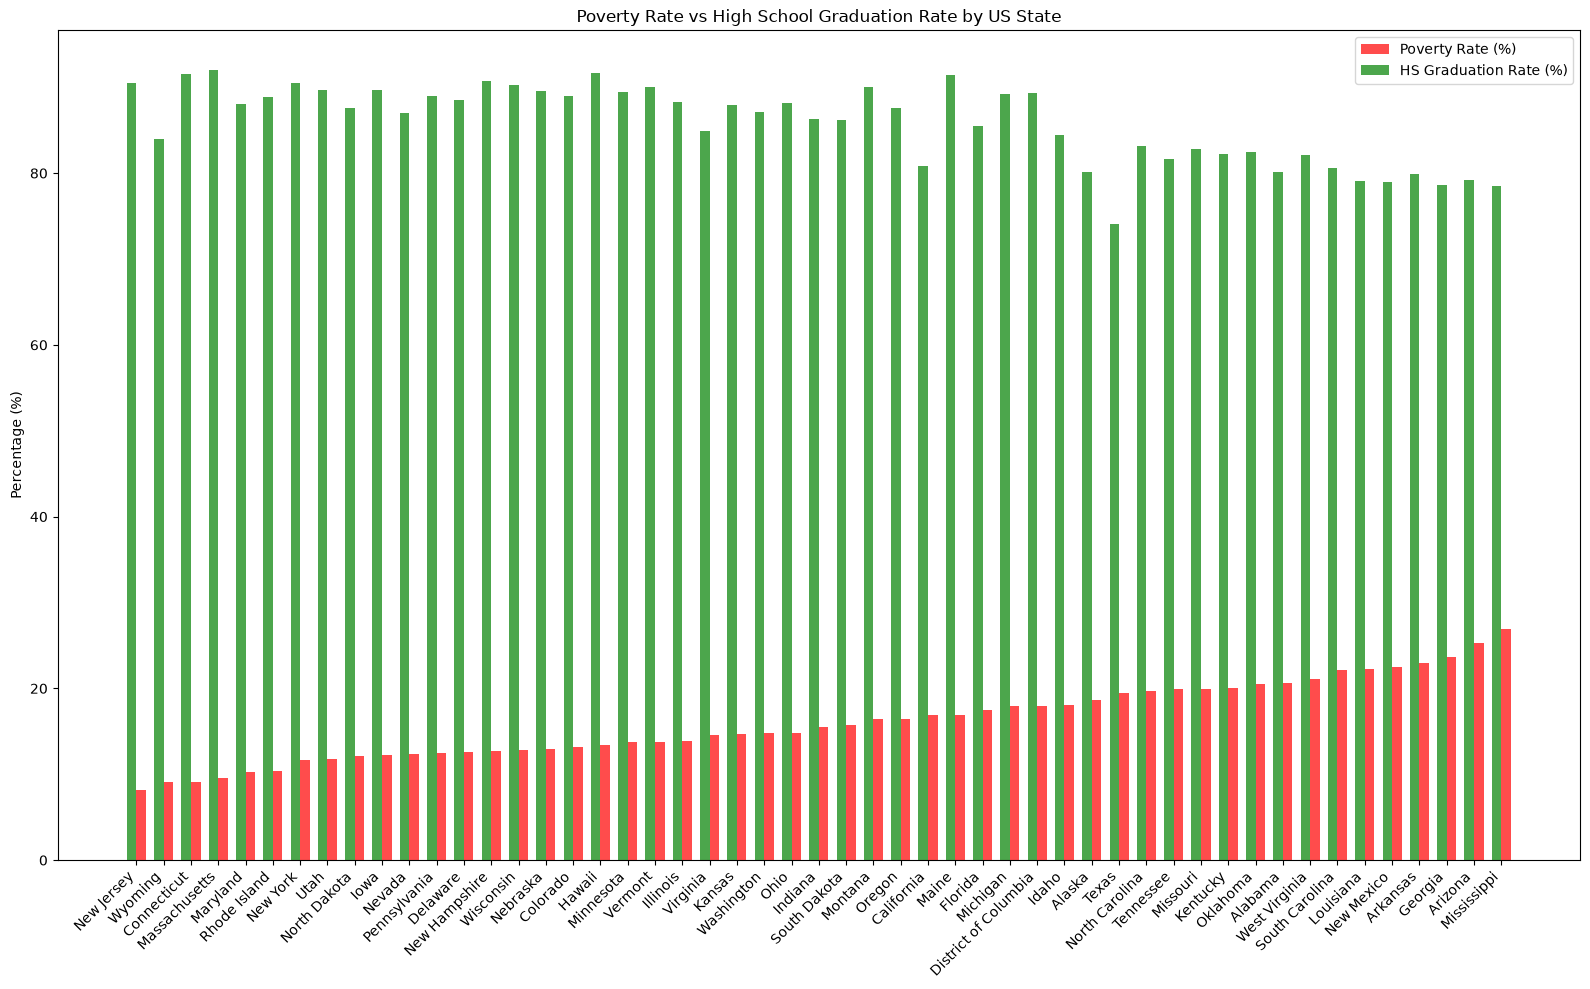

In [62]:
sorted_compare_hs_graduation_and_poverty = compare_hs_graduation_and_poverty.sort_values('avg_poverty_rate', ascending=True)
x = np.arange(len(sorted_compare_hs_graduation_and_poverty))  # label positions
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(16, 10))

bars1 = ax.bar(x + width/2, sorted_compare_hs_graduation_and_poverty['avg_poverty_rate'], width, label='Poverty Rate (%)', color='red', alpha=0.7)
bars2 = ax.bar(x - width/2, sorted_compare_hs_graduation_and_poverty['percent_completed_hs'], width, label='HS Graduation Rate (%)', color='green', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(
    sorted_compare_hs_graduation_and_poverty['state'] if 'state' in sorted_compare_hs_graduation_and_poverty.columns else sorted_compare_hs_graduation_and_poverty['Geographic Area'],
    rotation=45,
    ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Poverty Rate vs High School Graduation Rate by US State')
ax.legend()

plt.tight_layout()
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

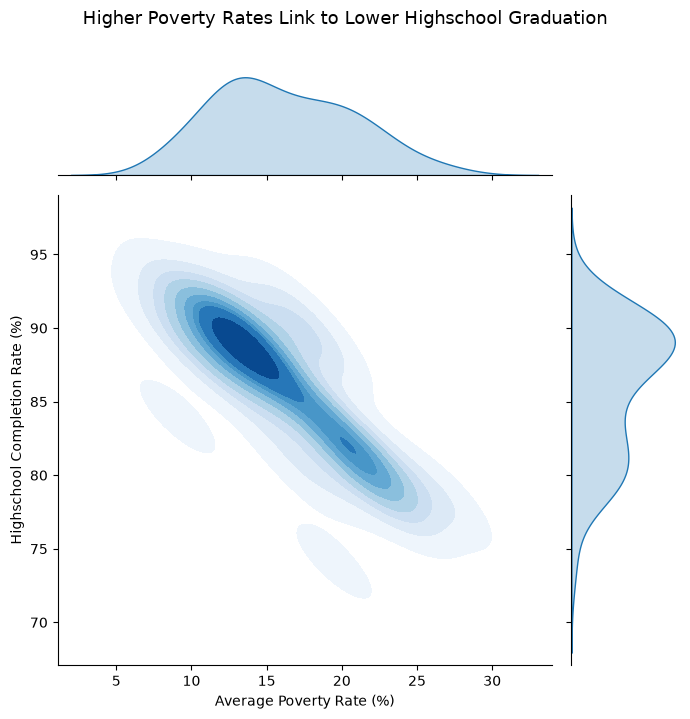

In [63]:
sns.jointplot(
    data=sorted_compare_hs_graduation_and_poverty,
    x="avg_poverty_rate",
    y="percent_completed_hs",
    kind="kde",                
    fill=True,
    cmap="Blues",
    height=7,
    ratio=4              
)

plt.suptitle("Higher Poverty Rates Link to Lower Highschool Graduation", y=1.02, fontsize=13)
plt.xlabel("Average Poverty Rate (%)")
plt.ylabel("Highschool Completion Rate (%)")
plt.tight_layout()
plt.show()

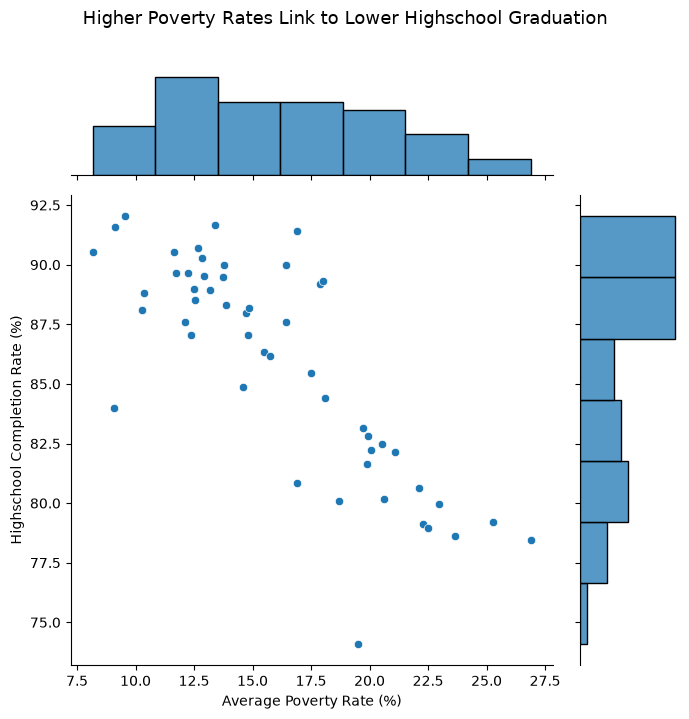

In [64]:
sns.jointplot(
    data=sorted_compare_hs_graduation_and_poverty,
    x="avg_poverty_rate",
    y="percent_completed_hs",
    kind="scatter",                
    height=7,
    ratio=4              
)

plt.suptitle("Higher Poverty Rates Link to Lower Highschool Graduation", y=1.02, fontsize=13)
plt.xlabel("Average Poverty Rate (%)")
plt.ylabel("Highschool Completion Rate (%)")
plt.tight_layout()
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

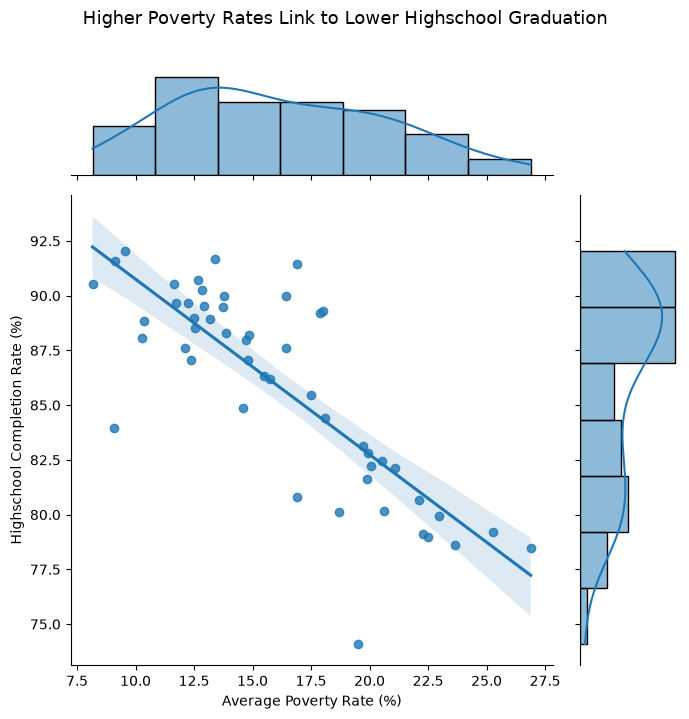

In [65]:
sns.jointplot(
    data=sorted_compare_hs_graduation_and_poverty,
    x="avg_poverty_rate",
    y="percent_completed_hs",
    kind="reg",                
    height=7,
    ratio=4              
)

plt.suptitle("Higher Poverty Rates Link to Lower Highschool Graduation", y=1.02, fontsize=13)
plt.xlabel("Average Poverty Rate (%)")
plt.ylabel("Highschool Completion Rate (%)")
plt.tight_layout()
plt.show()

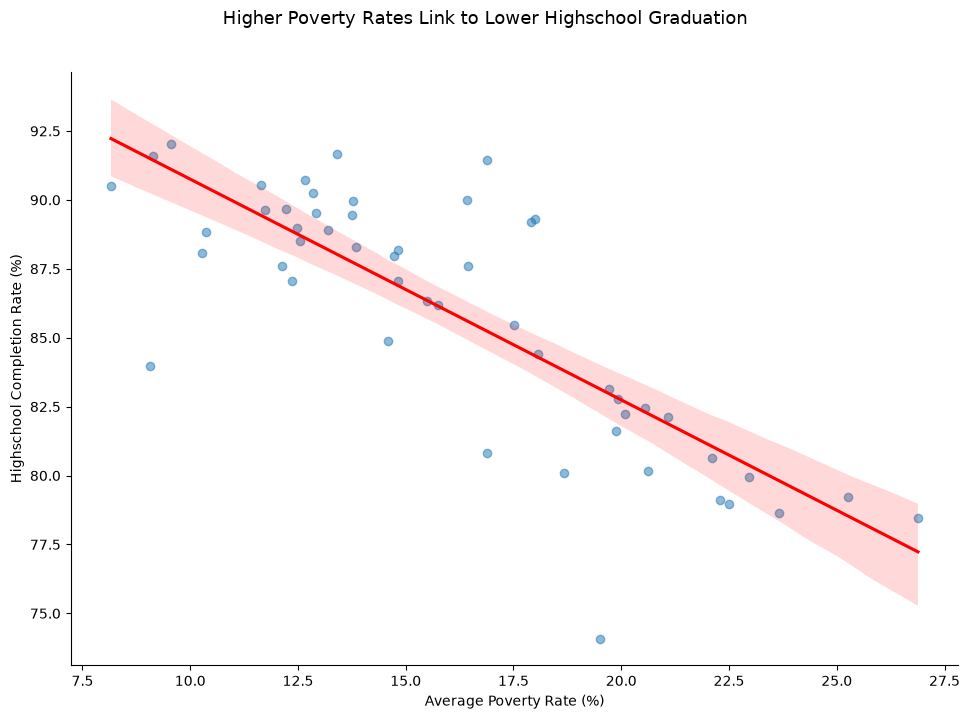

In [66]:
sns.lmplot(
    data=sorted_compare_hs_graduation_and_poverty,
    x="avg_poverty_rate",
    y="percent_completed_hs",           
    height=7,
    aspect=1.4,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}         
)

plt.suptitle("Higher Poverty Rates Link to Lower Highschool Graduation", y=1.02, fontsize=13)
plt.xlabel("Average Poverty Rate (%)")
plt.ylabel("Highschool Completion Rate (%)")
plt.tight_layout()
plt.show()

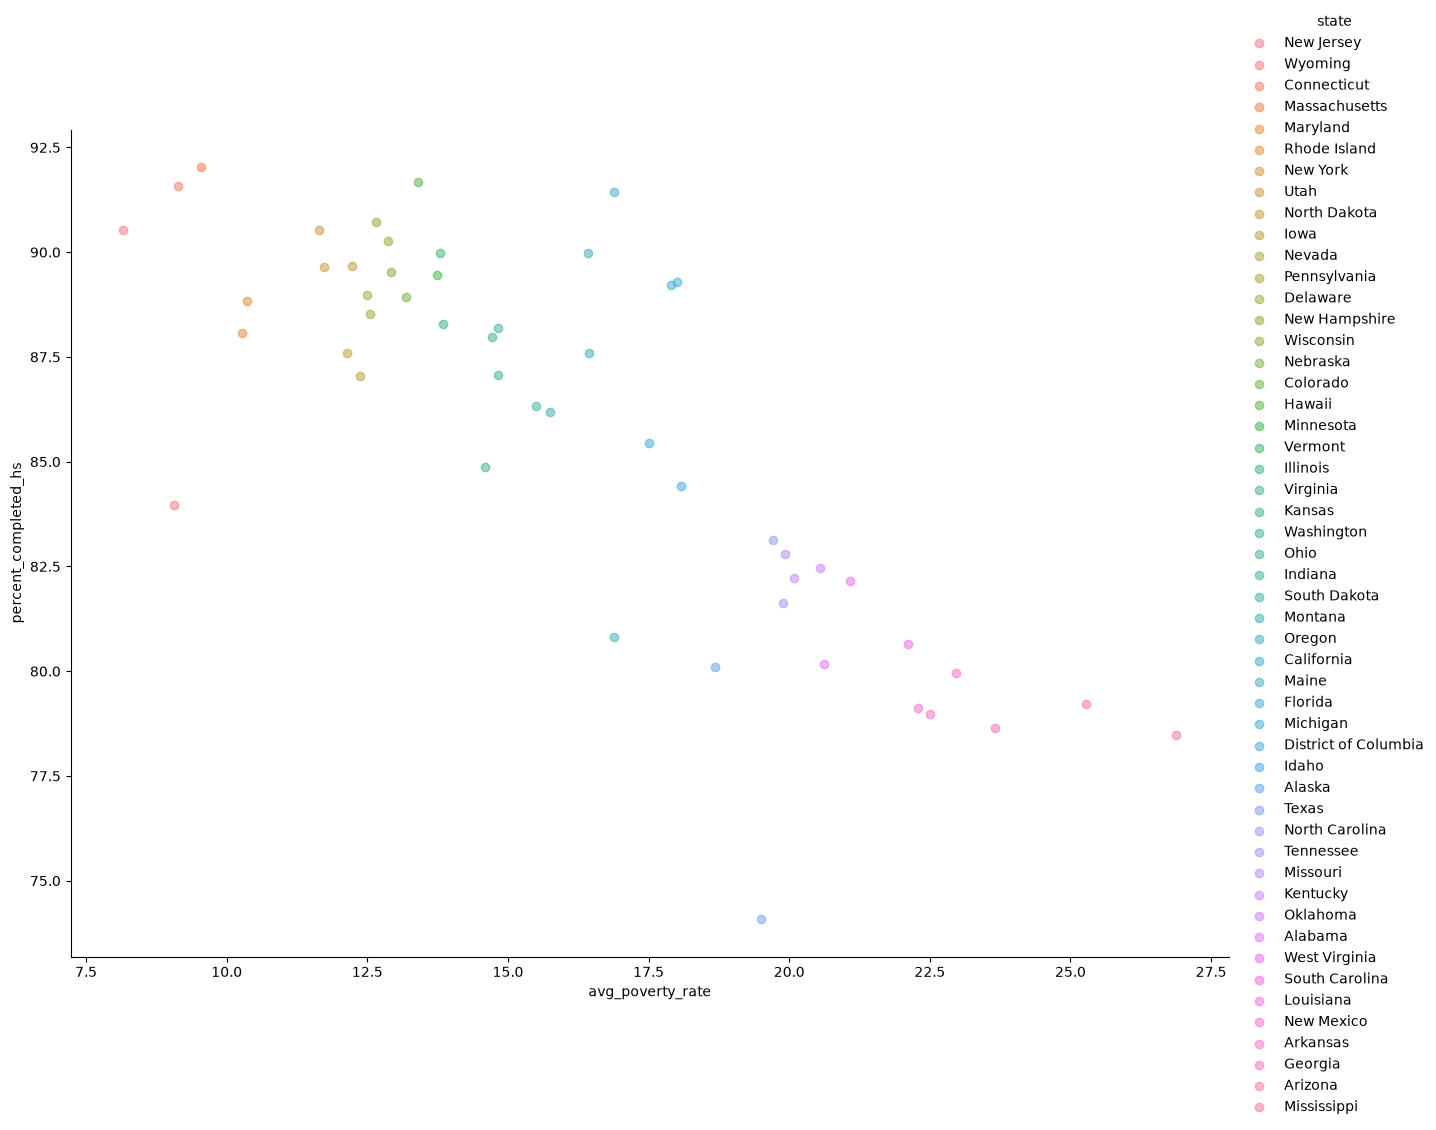

In [67]:
sns.lmplot(
    data=sorted_compare_hs_graduation_and_poverty,
    x="avg_poverty_rate",
    y="percent_completed_hs",
    hue="state",   # different colour per state/region
    height=9,
    aspect=1.4,
    scatter_kws={"alpha": 0.5}
)

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [68]:
print(df_share_race_by_city.columns.tolist())

['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']


In [69]:
df_state_race = df_share_race_by_city.groupby('Geographic area')[race_cols].mean().reset_index()

x = np.arange(len(df_state_race))
width = 0.2

# Convert to numeric first
race_cols = ['share_white', 'share_black', 'share_asian', 'share_hispanic']
df_state_race[race_cols] = df_state_race[race_cols].apply(pd.to_numeric, errors='coerce')

fig, ax = plt.subplots(figsize=(24, 10))

bars1 = ax.bar(x - 1.5*width, df_state_race['share_white'],    width, label='White',    color='steelblue', alpha=0.8)
bars2 = ax.bar(x - 0.5*width, df_state_race['share_black'],    width, label='Black',    color='tomato',    alpha=0.8)
bars3 = ax.bar(x + 0.5*width, df_state_race['share_asian'],    width, label='Asian',    color='seagreen',  alpha=0.8)
bars4 = ax.bar(x + 1.5*width, df_state_race['share_hispanic'], width, label='Hispanic', color='goldenrod', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(
    df_state_race['Geographic area'].map(state_abbreviations),
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_ylabel('Percentage (%)', fontsize=12, labelpad=15)
ax.set_title('Racial Composition Across US States', fontsize=14, pad=15)
ax.legend(title='Race', fontsize=11, title_fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{val:.0f}%'))
ax.set_ylim(0, df_state_race[race_cols].max().max() * 1.1)  # now after ax exists

plt.tight_layout()
plt.show()

NameError: name 'race_cols' is not defined

In [ ]:
race_cols = ['share_white', 'share_black', 'share_asian', 'share_hispanic']
df_share_race_by_city[race_cols] = df_share_race_by_city[race_cols].apply(pd.to_numeric, errors='coerce')

df_state_race = df_share_race_by_city.groupby('Geographic area')[race_cols].mean().reset_index()

# Rename to match other dataframes
df_state_race = df_state_race.rename(columns={'Geographic area': 'state_abbreviation'})

# Add full state name
df_state_race['state'] = df_state_race['state_abbreviation'].map(state_abbreviations)

# print(df_state_race.head())

In [ ]:
race_and_poverty = df_state_race.merge(
    df_poverty_by_state,
    on = 'state',
    how = 'left'
)
# print(race_and_poverty.head())

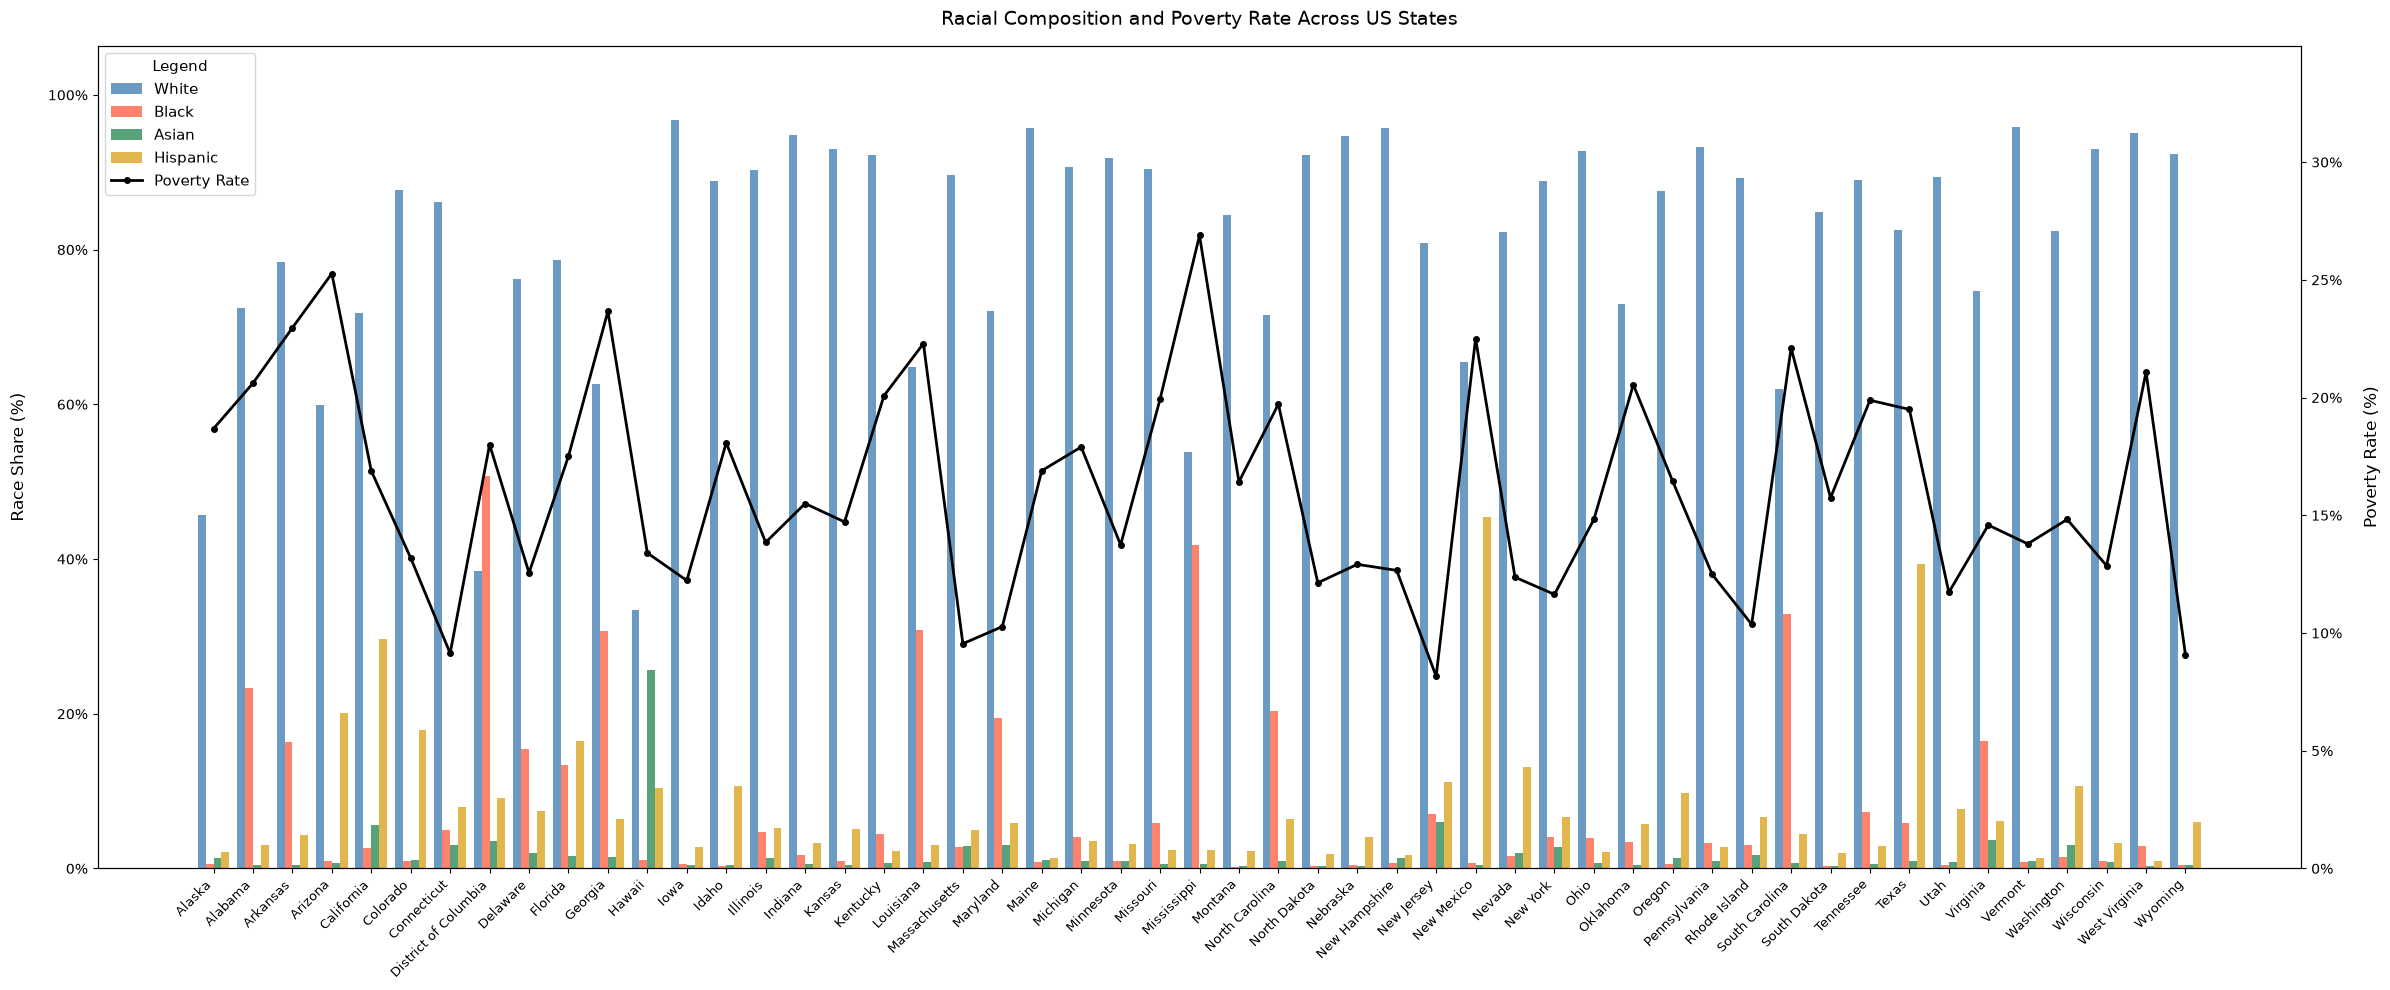

In [ ]:
x = np.arange(len(df_state_race))
width = 0.2

fig, ax = plt.subplots(figsize=(24, 10))

ax.bar(x - 1.5*width, race_and_poverty['share_white'],    width, label='White',    color='steelblue', alpha=0.8)
ax.bar(x - 0.5*width, race_and_poverty['share_black'],    width, label='Black',    color='tomato',    alpha=0.8)
ax.bar(x + 0.5*width, race_and_poverty['share_asian'],    width, label='Asian',    color='seagreen',  alpha=0.8)
ax.bar(x + 1.5*width, race_and_poverty['share_hispanic'], width, label='Hispanic', color='goldenrod', alpha=0.8)

# Second y-axis for poverty rate
ax2 = ax.twinx()
ax2.plot(x, race_and_poverty['avg_poverty_rate'], color='black', linewidth=2, marker='o', markersize=4, label='Poverty Rate')
ax2.set_ylabel('Poverty Rate (%)', fontsize=12, labelpad=15)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{val:.0f}%'))
ax2.set_ylim(0, race_and_poverty['avg_poverty_rate'].max() * 1.3)

ax.set_xticks(x)
ax.set_xticklabels(
    race_and_poverty['state'],
    rotation=45,
    ha='right',
    fontsize=9
)

ax.set_ylabel('Race Share (%)', fontsize=12, labelpad=15)
ax.set_title('Racial Composition and Poverty Rate Across US States', fontsize=14, pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{val:.0f}%'))
ax.set_ylim(0, race_and_poverty[race_cols].max().max() * 1.1)

# Combine both legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, title='Legend', fontsize=11, title_fontsize=11)

plt.tight_layout()
plt.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [ ]:
df_deaths_by_police.columns
df_deaths_by_police.head(5)

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [ ]:
# print(df_deaths_by_police['race'].unique())
# print(df_deaths_by_police['race'].isna().sum())

In [ ]:
df_deaths_by_race = df_deaths_by_police.groupby('race').size().reset_index(name='count')

race_map = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other',
    'Unknown': 'Unknown'
}

df_deaths_by_race['race_name'] = df_deaths_by_race['race'].map(race_map)
df_deaths_by_race = df_deaths_by_race.sort_values('count', ascending=False).reset_index(drop=True)

# print(df_deaths_by_race)

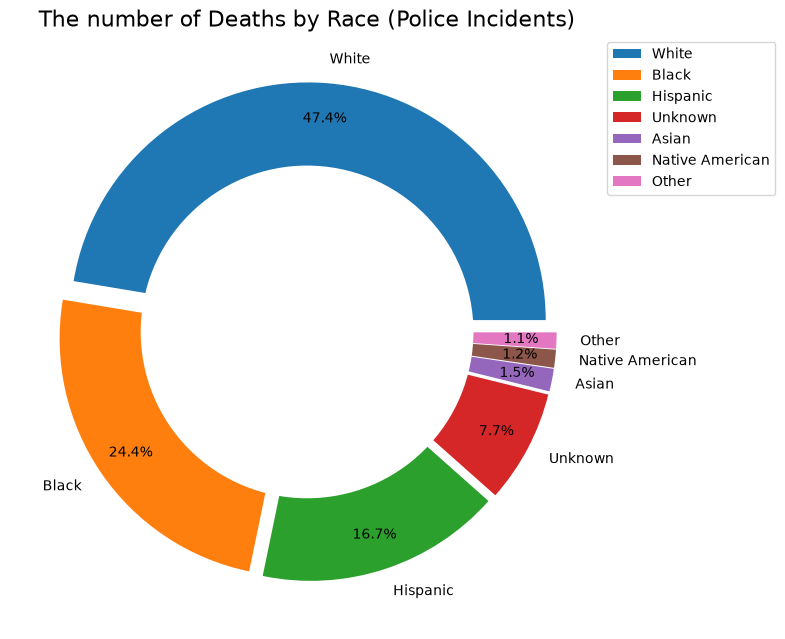

In [ ]:
explode = [0.05] * len(df_deaths_by_race)

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    df_deaths_by_race['count'],
    labels=df_deaths_by_race['race_name'],
    autopct='%1.1f%%', 
    pctdistance=0.85, 
    explode=explode
    )
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)
ax.set_title(
    "The number of Deaths by Race (Police Incidents)", 
    fontsize=16,
    fontfamily='DejaVu Sans'
    )

plt.legend(
    labels=df_deaths_by_race['race_name'],
    loc='upper right',
    bbox_to_anchor=(1.3, 1)  
)

plt.tight_layout()
plt.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [ ]:
df_fatalities = df_deaths_by_police.groupby('gender').size().reset_index(name='count')
gender_map = {
    'F': 'Female',
    'M': 'Male'
}
df_fatalities['gender_name'] = df_fatalities['gender'].map(gender_map)
df_fatalities = df_fatalities.sort_values('count', ascending=False).reset_index(drop=True)

df_fatalities

,gender,count,gender_name
0,M,2428,Male
1,F,107,Female


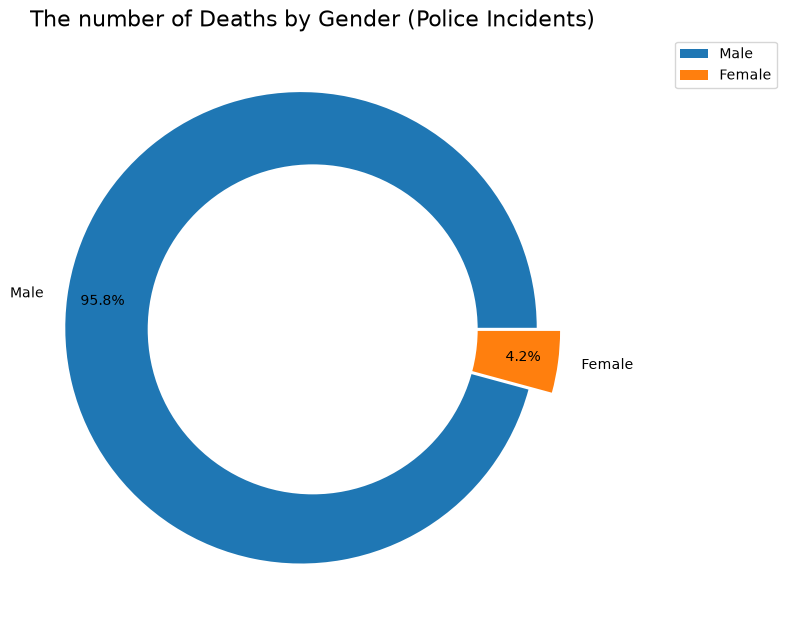

In [ ]:
explode = [0.05] * len(df_fatalities)

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    df_fatalities['count'],
    labels=df_fatalities['gender_name'],
    autopct='%1.1f%%', 
    pctdistance=0.85, 
    explode=explode
    )
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)
ax.set_title(
    "The number of Deaths by Gender (Police Incidents)", 
    fontsize=16,
    fontfamily='DejaVu Sans'
    )

plt.legend(
    labels=df_fatalities['gender_name'],
    loc='upper right',
    bbox_to_anchor=(1.3, 1)  
)

plt.tight_layout()
plt.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [70]:
df_deaths_by_police.head(5)

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [ ]:
# Create age bins
bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_deaths_by_police['age_group'] = pd.cut(df_deaths_by_police['age'], bins=bins, labels=age_labels)
df_gender_age = df_deaths_by_police.groupby(['gender', 'age_group']).size().reset_index(name='count')
df_gender_age['gender_name'] = df_gender_age['gender'].map({'M': 'Male', 'F': 'Female'}).fillna('Unknown')
# print(df_gender_age)

df_deaths_by_police['age_group'] = pd.cut(df_deaths_by_police['age'], bins=bins, labels=age_labels)
df_deaths_by_police['gender_name'] = df_deaths_by_police['gender'].map({'M': 'Male', 'F': 'Female'}).fillna('Unknown')
df_manner_gender_age = df_deaths_by_police.groupby(['manner_of_death', 'gender_name', 'age_group']).size().reset_index(name='count')
print(df_manner_gender_age)

   gender age_group  count gender_name
0       F  Under 18      7      Female
1       F     18-24     18      Female
2       F     25-34     26      Female
3       F     35-44     26      Female
4       F     45-54     19      Female
5       F     55-64      6      Female
6       F       65+      2      Female
7       M  Under 18     98        Male
8       M     18-24    430        Male
9       M     25-34    734        Male
10      M     35-44    520        Male
11      M     45-54    345        Male
12      M     55-64    169        Male
13      M       65+     58        Male
     manner_of_death gender_name age_group  count
0               shot      Female  Under 18      6
1               shot      Female     18-24     18
2               shot      Female     25-34     25
3               shot      Female     35-44     24
4               shot      Female     45-54     18
5               shot      Female     55-64      6
6               shot      Female       65+      2
7              

In [85]:
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go
pio.renderers.default = 'browser'

def build_sunburst_data(gender):
    df = df_manner_gender_age[df_manner_gender_age['gender_name'] == gender].copy()
    df['age_group'] = df['age_group'].astype(str)
    df_grouped = df.groupby(['age_group', 'manner_of_death'], observed=True)['count'].sum().reset_index()
    df_age = df_grouped.groupby('age_group')['count'].sum().reset_index()

    # Restore chronological order after astype(str) drops the Categorical
    age_order = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
    df_age['age_group'] = pd.Categorical(df_age['age_group'], categories=age_order, ordered=True)
    df_age = df_age.sort_values('age_group')
    df_grouped['age_group'] = pd.Categorical(df_grouped['age_group'], categories=age_order, ordered=True)
    df_grouped = df_grouped.sort_values('age_group')

    df_grouped['leaf_label'] = df_grouped['age_group'].astype(str) + '|' + df_grouped['manner_of_death']
    labels  = list(df_age['age_group'].astype(str)) + list(df_grouped['leaf_label'])
    parents = [''] * len(df_age) + list(df_grouped['age_group'].astype(str))
    values  = list(df_age['count']) + list(df_grouped['count'])
    text    = list(df_age['age_group'].astype(str)) + list(df_grouped['manner_of_death'])

    return labels, parents, values, text

male_labels,   male_parents,   male_values,   male_text   = build_sunburst_data('Male')
female_labels, female_parents, female_values, female_text = build_sunburst_data('Female')


# ── Gender overview data ───────────────────────────────────────────────
df_gender = df_manner_gender_age.groupby('gender_name')['count'].sum().reset_index()

# ── Layout: 3 subplots ─────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'domain'}, {'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=['Female Breakdown', 'Gender Overview', 'Male Breakdown']
)

# ── Left — Female sunburst ─────────────────────────────────────────────
fig.add_trace(go.Sunburst(
    labels=female_labels,
    parents=female_parents,
    values=female_values,
    text=female_text,
    texttemplate='%{text}<br>%{percentParent:.1%}',
    branchvalues='total',
    marker=dict(colorscale='RdPu'),
    hovertemplate='<b>%{label}</b><br>Count: %{value}<extra></extra>',
    name='Female'
), row=1, col=1)

# ── Centre — Gender donut ──────────────────────────────────────────────
fig.add_trace(go.Pie(
    labels=df_gender['gender_name'],
    values=df_gender['count'],
    hole=0.5,
    marker=dict(colors=['tomato', 'steelblue']),
    textinfo='label+percent',
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>%{percent}<extra></extra>',
    name='Gender'
), row=1, col=2)

# ── Right — Male sunburst ──────────────────────────────────────────────
fig.add_trace(go.Sunburst(
    labels=male_labels,
    parents=male_parents,
    values=male_values,
    text=male_text,
    texttemplate='%{text}<br>%{percentParent:.1%}',
    branchvalues='total',
    marker=dict(colorscale='Blues'),
    hovertemplate='<b>%{label}</b><br>Count: %{value}<extra></extra>',
    name='Male'
), row=1, col=3)

# ── Layout ─────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='Police Fatalities: Gender Overview with Age & Manner of Death Breakdown',
        x=0.5,
        font=dict(size=16)
    ),
    height=650,
    margin=dict(t=80, l=20, r=20, b=20),
    showlegend = False
)

fig.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [93]:
# df_deaths_by_police.head(5)
df_deaths_by_police.groupby(['armed']).value_counts().sort_values(ascending=True)
print(df_deaths_by_police['armed'].unique())

<StringArray>
[                             'gun',                          'unarmed',
                       'toy weapon',                         'nail gun',
                            'knife',                          'vehicle',
                           'shovel',                           'hammer',
                          'hatchet',                     'undetermined',
                            'sword',                          'machete',
                       'box cutter',                     'metal object',
                      'screwdriver',                 'lawn mower blade',
                         'flagpole',              'guns and explosives',
                   'cordless drill',                         'crossbow',
                       'metal pole',                            'Taser',
                       'metal pipe',                  'metal hand tool',
                     'blunt object',                      'metal stick',
                     'sharp object', 

In [91]:
# Map to armed or unarmed
armed_map = lambda x: 'Unarmed' if x == 'unarmed' else 'Armed'
df_deaths_by_police['armed_status'] = df_deaths_by_police['armed'].apply(armed_map)
df_deaths_by_police.head(5)

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,age_group,gender_name,armed_status
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,45-54,Male,Armed
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,45-54,Male,Armed
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,18-24,Male,Unarmed
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,25-34,Male,Armed
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,35-44,Male,Armed


In [126]:
import plotly.io as pio
import plotly.graph_objects as go
import pandas as pd
import textwrap

pio.renderers.default = 'browser'

def wrap_annotation(text, width=60):
    # Split on existing <br> first, then wrap each line
    lines = text.split('<br>')
    wrapped = []
    for line in lines:
        wrapped.append('<br>'.join(textwrap.wrap(line, width=width)))
    return '<br>'.join(wrapped)

# ── Config ─────────────────────────────────────────────────────────────
THRESHOLD = 20

# ── Armed status column ────────────────────────────────────────────────
df_deaths_by_police['armed_status'] = df_deaths_by_police['armed'].apply(
    lambda x: 'Unarmed' if x == 'unarmed' else 'Armed'
)

# ── Weapon counts ───────────────────────────────────────────────────────
df_weapons = df_deaths_by_police.groupby(['armed_status', 'armed']).size().reset_index(name='count')

# ── Split into main and other ───────────────────────────────────────────
df_main  = df_weapons[df_weapons['count'] >= THRESHOLD].copy()
df_other = df_weapons[df_weapons['count'] <  THRESHOLD].copy()

# ── Build "Other" rows per armed_status ────────────────────────────────
other_rows = df_other.groupby('armed_status')['count'].sum().reset_index()
other_rows['armed'] = other_rows['armed_status'].map({
    'Armed':   'Armed - Other',
    'Unarmed': 'Unarmed - Other'
})
df_main = pd.concat([df_main, other_rows], ignore_index=True)

# ── Inner ring: Unarmed first, then Armed ──────────────────────────────
status_order = ['Unarmed', 'Armed']
df_inner = df_main.groupby('armed_status')['count'].sum().reset_index()
df_inner = df_inner.set_index('armed_status').loc[status_order].reset_index()

# ── Outer ring: Unarmed first, then Armed sorted by count descending ───
df_unarmed_outer = df_main[df_main['armed_status'] == 'Unarmed'].sort_values('count', ascending=False)
df_armed_outer   = df_main[df_main['armed_status'] == 'Armed'].sort_values('count', ascending=True)
df_main = pd.concat([df_unarmed_outer, df_armed_outer], ignore_index=True)

# ── Build sunburst lists ────────────────────────────────────────────────
labels  = list(df_inner['armed_status']) + list(df_main['armed'])
parents = [''] * len(df_inner) + list(df_main['armed_status'])
values  = list(df_inner['count']) + list(df_main['count'])

# ── Rotation: boundary between Unarmed and Armed lands at 12 o'clock ──
total         = sum(values[:len(df_inner)])  # inner ring total
unarmed_total = df_inner[df_inner['armed_status'] == 'Unarmed']['count'].values[0]
unarmed_angle = (unarmed_total / total) * 360
rotation      = 90 + (unarmed_angle / 2)

# ── Footnote ───────────────────────────────────────────────────────────
other_items = df_other.sort_values('count', ascending=False)
footnote_lines = []
for status, grp in other_items.groupby('armed_status'):
    items = ', '.join(f"{row['armed']} ({row['count']})" for _, row in grp.iterrows())
    footnote_lines.append(f"<b>{status} – Other:</b> {items}")
footnote = '<br>'.join(footnote_lines)

# ── Footnote wrapping ──────────────────────────────────────────────────
footnote_wrapped = wrap_annotation(footnote, width=40)

# ── Figure ─────────────────────────────────────────────────────────────
fig = go.Figure(go.Sunburst(
    labels=labels,
    parents=parents,
    values=values,
    branchvalues='total',
    sort=False,
    rotation=rotation,
    insidetextorientation='horizontal',
    textinfo='label+percent parent',
    hovertemplate='<b>%{label}</b><br>Count: %{value}<br>%{percentRoot:.1%} of total<extra></extra>',
    marker=dict(colorscale='YlOrRd')
))

fig.update_layout(
    title=dict(
        text='Armed Status & Weapon Types in Police Fatalities',
        x=0.5,
        font=dict(size=16)
    ),
    height=650,
    annotations=[dict(
        x=1.05,
        y=1.0,
        xref='paper', yref='paper',
        xanchor='left', yanchor='top',
        text=f'* Other includes weapons with fewer than {THRESHOLD} incidents:<br><br>{footnote_wrapped}',
        showarrow=False,
        font=dict(size=10, color='grey'),
        align='left'
    )],
    margin=dict(t=80, l=20, r=300, b=20),
)

fig.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [130]:
total_deaths = len(df_deaths_by_police)
under_25 = len(df_deaths_by_police[df_deaths_by_police['age'] < 25])
percentage = (under_25 / total_deaths) * 100
print(f"Under 25: {under_25} out of {total_deaths} total ({percentage:.1f}%)")

Under 25: 527 out of 2535 total (20.8%)


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

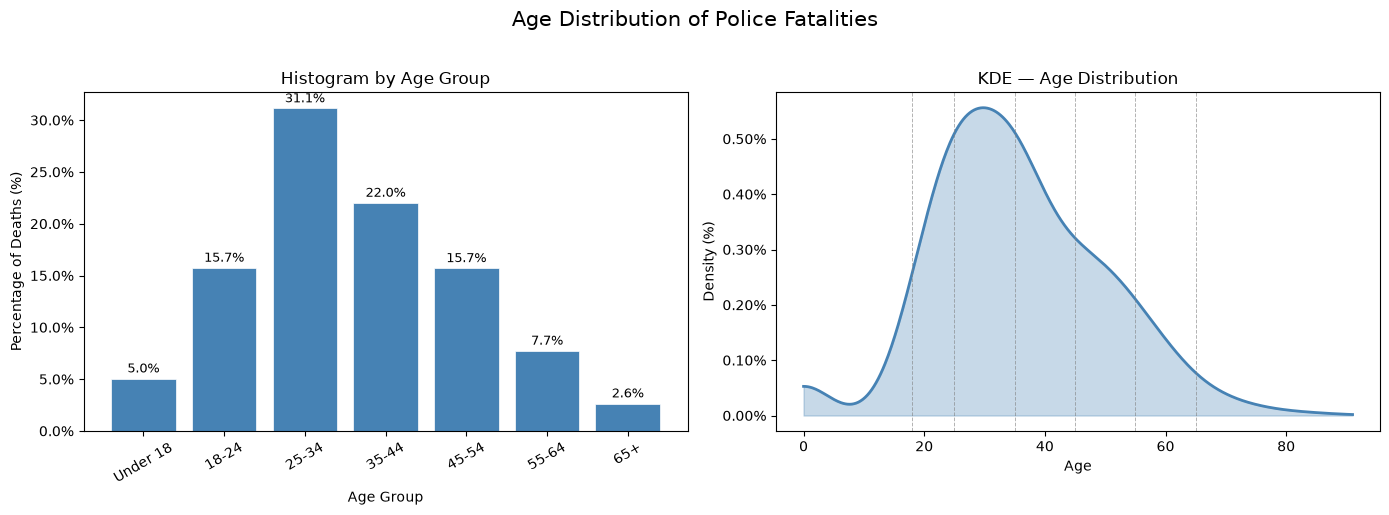

In [131]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import gaussian_kde
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution of Police Fatalities', fontsize=15, y=1.02)

ages = df_deaths_by_police['age'].dropna()
total = len(ages)

# ── Left: Histogram ────────────────────────────────────────────────────
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

counts, edges = np.histogram(ages, bins=bins)
percentages = (counts / total) * 100

bars = axes[0].bar(labels, percentages, color='steelblue', edgecolor='white', linewidth=0.5)

# Add percentage labels on top of each bar
for bar, pct in zip(bars, percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title('Histogram by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Percentage of Deaths (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=30)

# ── Right: KDE ─────────────────────────────────────────────────────────
kde = gaussian_kde(ages, bw_method=0.3)
x = np.linspace(ages.min(), ages.max(), 500)
y = kde(x)
y_pct = (y / y.sum()) * 100

axes[1].plot(x, y_pct, color='steelblue', linewidth=2)
axes[1].fill_between(x, y_pct, alpha=0.3, color='steelblue')

# Add vertical lines for age group boundaries
for boundary in [18, 25, 35, 45, 55, 65]:
    axes[1].axvline(x=boundary, color='grey', linestyle='--', linewidth=0.7, alpha=0.6)

axes[1].set_title('KDE — Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

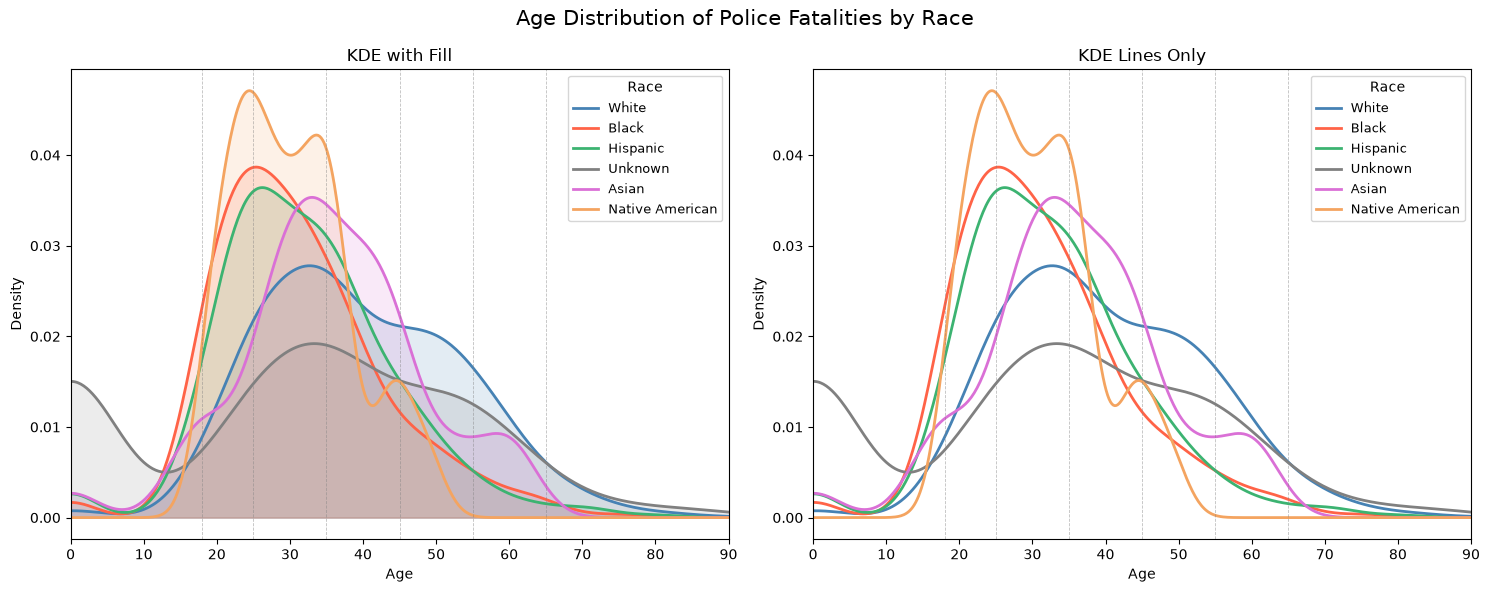

In [132]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

# ── Get races with enough data for KDE ─────────────────────────────────
min_count = 30
race_counts = df_deaths_by_police['race'].value_counts()
valid_races = race_counts[race_counts >= min_count].index.tolist()

df_kde = df_deaths_by_police[df_deaths_by_police['race'].isin(valid_races)].dropna(subset=['age', 'race'])

# ── Colour palette per race ─────────────────────────────────────────────
colors = {
    'W': ('steelblue',   'White'),
    'B': ('tomato',      'Black'),
    'H': ('mediumseagreen', 'Hispanic'),
    'A': ('orchid',      'Asian'),
    'N': ('sandybrown',  'Native American'),
    'O': ('gold',        'Other'),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Age Distribution of Police Fatalities by Race', fontsize=15)

for race in valid_races:
    ages = df_kde[df_kde['race'] == race]['age']
    color, label = colors.get(race, ('grey', race))

    kde = gaussian_kde(ages, bw_method=0.3)
    x = np.linspace(0, 100, 500)
    y = kde(x)

    # ── Left: filled KDE ───────────────────────────────────────────────
    axes[0].plot(x, y, color=color, linewidth=2, label=label)
    axes[0].fill_between(x, y, alpha=0.15, color=color)

    # ── Right: lines only, easier to compare peaks ─────────────────────
    axes[1].plot(x, y, color=color, linewidth=2, label=label)

for ax in axes:
    ax.set_xlabel('Age')
    ax.set_ylabel('Density')
    ax.legend(title='Race', fontsize=9)
    ax.set_xlim(0, 90)
    for boundary in [18, 25, 35, 45, 55, 65]:
        ax.axvline(x=boundary, color='grey', linestyle='--', linewidth=0.6, alpha=0.5)

axes[0].set_title('KDE with Fill')
axes[1].set_title('KDE Lines Only')

plt.tight_layout()
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

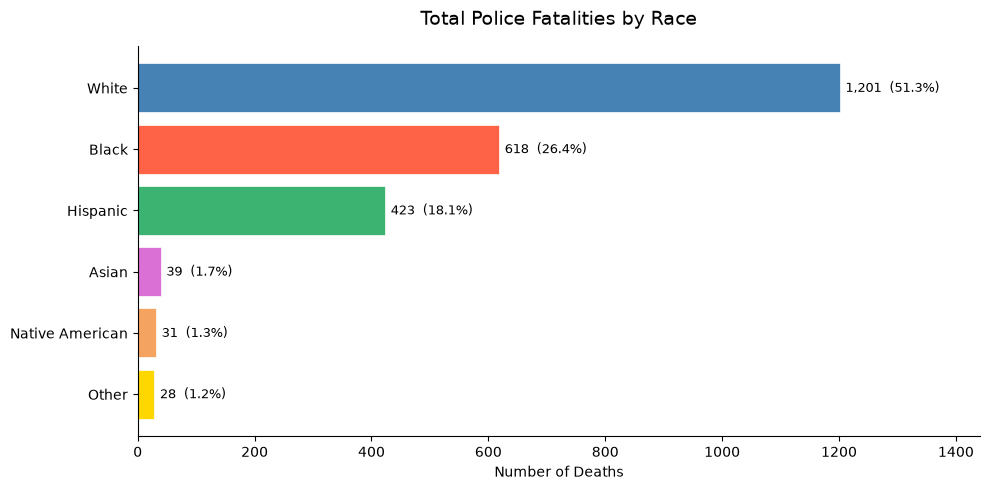

In [133]:
import matplotlib.pyplot as plt

race_labels = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other',
}

colors = {
    'W': 'steelblue',
    'B': 'tomato',
    'H': 'mediumseagreen',
    'A': 'orchid',
    'N': 'sandybrown',
    'O': 'gold',
}

df_race = df_deaths_by_police['race'].value_counts().reset_index()
df_race.columns = ['race', 'count']
df_race = df_race[df_race['race'].isin(race_labels)]
df_race['label'] = df_race['race'].map(race_labels)
df_race['color'] = df_race['race'].map(colors)
df_race = df_race.sort_values('count', ascending=True)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(df_race['label'], df_race['count'],
               color=df_race['color'], edgecolor='white', linewidth=0.5)

# ── Count + percentage labels ──────────────────────────────────────────
total = df_race['count'].sum()
for bar, (_, row) in zip(bars, df_race.iterrows()):
    pct = (row['count'] / total) * 100
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{row['count']:,}  ({pct:.1f}%)",
        va='center', fontsize=9
    )

ax.set_title('Total Police Fatalities by Race', fontsize=14, pad=15)
ax.set_xlabel('Number of Deaths')
ax.set_xlim(0, df_race['count'].max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [134]:
total = len(df_deaths_by_police)
mental_health = df_deaths_by_police['signs_of_mental_illness'].sum()
percentage = (mental_health / total) * 100
print(f"Mental health issues: {mental_health} out of {total} total ({percentage:.1f}%)")

Mental health issues: 633 out of 2535 total (25.0%)


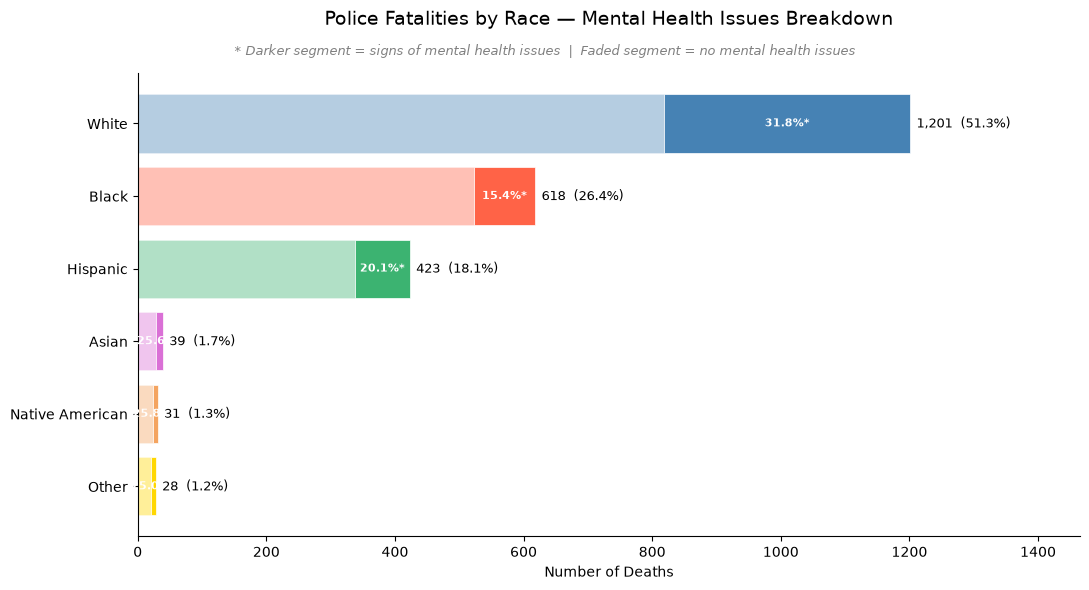

In [145]:
race_labels = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other',
}

colors = {
    'W': 'steelblue',
    'B': 'tomato',
    'H': 'mediumseagreen',
    'A': 'orchid',
    'N': 'sandybrown',
    'O': 'gold',
}

df_race_mental = df_deaths_by_police[df_deaths_by_police['race'].isin(race_labels)].copy()
df_race_mental = df_race_mental.groupby('race').agg(
    total=('race', 'count'),
    mental_health=('signs_of_mental_illness', 'sum')
).reset_index()
df_race_mental['no_mental_health'] = df_race_mental['total'] - df_race_mental['mental_health']
df_race_mental['label'] = df_race_mental['race'].map(race_labels)
df_race_mental['color'] = df_race_mental['race'].map(colors)
df_race_mental = df_race_mental.sort_values('total', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

# ── Stacked bars ───────────────────────────────────────────────────────
ax.barh(df_race_mental['label'], df_race_mental['no_mental_health'],
        color=df_race_mental['color'], alpha=0.4,
        edgecolor='white', linewidth=0.5)

ax.barh(df_race_mental['label'], df_race_mental['mental_health'],
        left=df_race_mental['no_mental_health'],
        color=df_race_mental['color'], alpha=1.0,
        edgecolor='white', linewidth=0.5)

# ── Labels ─────────────────────────────────────────────────────────────
total_all = df_race_mental['total'].sum()
for _, row in df_race_mental.iterrows():
    pct_mh    = (row['mental_health'] / row['total']) * 100
    pct_total = (row['total'] / total_all) * 100

    # Mental health % inside the darker segment
    ax.text(
        row['no_mental_health'] + row['mental_health'] / 2,
        list(df_race_mental['label']).index(row['label']),
        f"{pct_mh:.1f}%*",
        ha='center', va='center', fontsize=8, color='white', fontweight='bold'
    )

    # Total count + % of all deaths at end of bar
    ax.text(
        row['total'] + 10,
        list(df_race_mental['label']).index(row['label']),
        f"{row['total']:,}  ({pct_total:.1f}%)",
        va='center', fontsize=9
    )

ax.set_title('Police Fatalities by Race — Mental Health Issues Breakdown', fontsize=14, pad=35)
ax.set_xlabel('Number of Deaths')
ax.set_xlim(0, df_race_mental['total'].max() * 1.22)
ax.spines[['top', 'right']].set_visible(False)

# ── Footnote ───────────────────────────────────────────────────────────
fig.text(0.5, 0.9,
         '* Darker segment = signs of mental health issues  |  Faded segment = no mental health issues',
         fontsize=9, color='grey', ha='center', style='italic')

plt.tight_layout()
plt.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

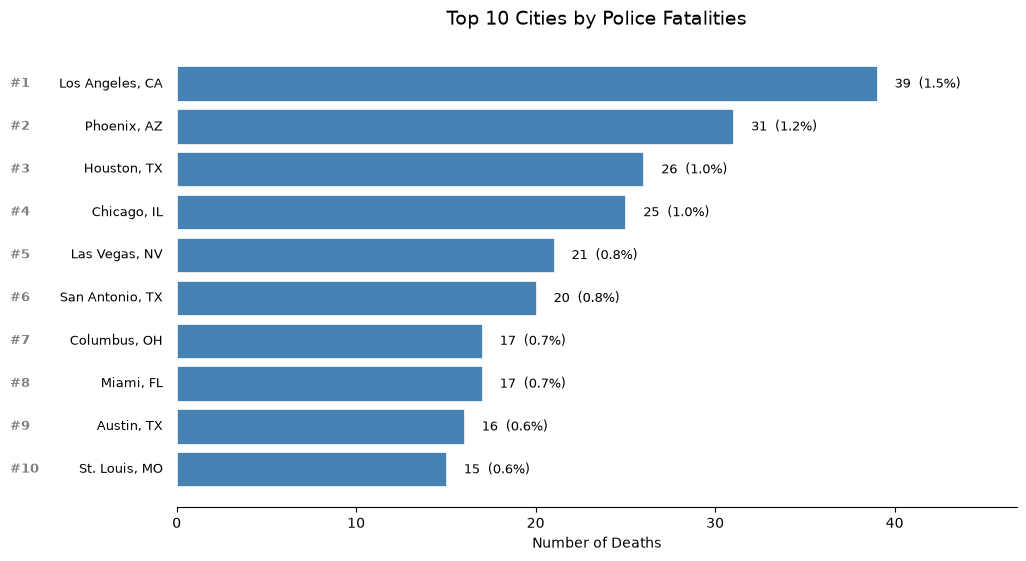

In [157]:
import matplotlib.pyplot as plt

df_cities = df_deaths_by_police.groupby(['city', 'state']).size().reset_index(name='count')
df_cities = df_cities.sort_values('count', ascending=False).head(10)
df_cities = df_cities.sort_values('count', ascending=True)


total = len(df_deaths_by_police)
df_cities['rank'] = range(len(df_cities), 0, -1)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(range(len(df_cities)), df_cities['count'],
               color='steelblue', edgecolor='white', linewidth=0.5)

# ── Count labels at end of bar ─────────────────────────────────────────
for bar, (_, row) in zip(bars, df_cities.iterrows()):
    pct = (row['count'] / total) * 100
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{row['count']:,}  ({pct:.1f}%)",
        va='center', fontsize=9
    )

# ── Rank and city labels using figure transform ────────────────────────
for i, (_, row) in enumerate(df_cities.iterrows()):
    # Rank — fixed far left in figure space
    ax.annotate(
        f"#{row['rank']}",
        xy=(0, i), xycoords=('axes fraction', 'data'),
        xytext=(-120, 0), textcoords='offset points',
        ha='left', va='center', fontsize=9,
        color='grey', fontweight='bold'
    )
    # City — right-aligned just before bar
    # City, state — right-aligned just before bar
    ax.annotate(
        f"{row['city']}, {row['state']}",
        xy=(0, i), xycoords=('axes fraction', 'data'),
        xytext=(-10, 0), textcoords='offset points',
        ha='right', va='center', fontsize=9,
    )

ax.set_yticks([])
ax.set_title('Top 10 Cities by Police Fatalities', fontsize=14, pad=15)
ax.set_xlabel('Number of Deaths')
ax.set_xlim(0, df_cities['count'].max() * 1.2)
ax.spines[['top', 'right', 'left']].set_visible(False)

# ── Extra left margin for rank + city labels ───────────────────────────
plt.subplots_adjust(left=0.2)

plt.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

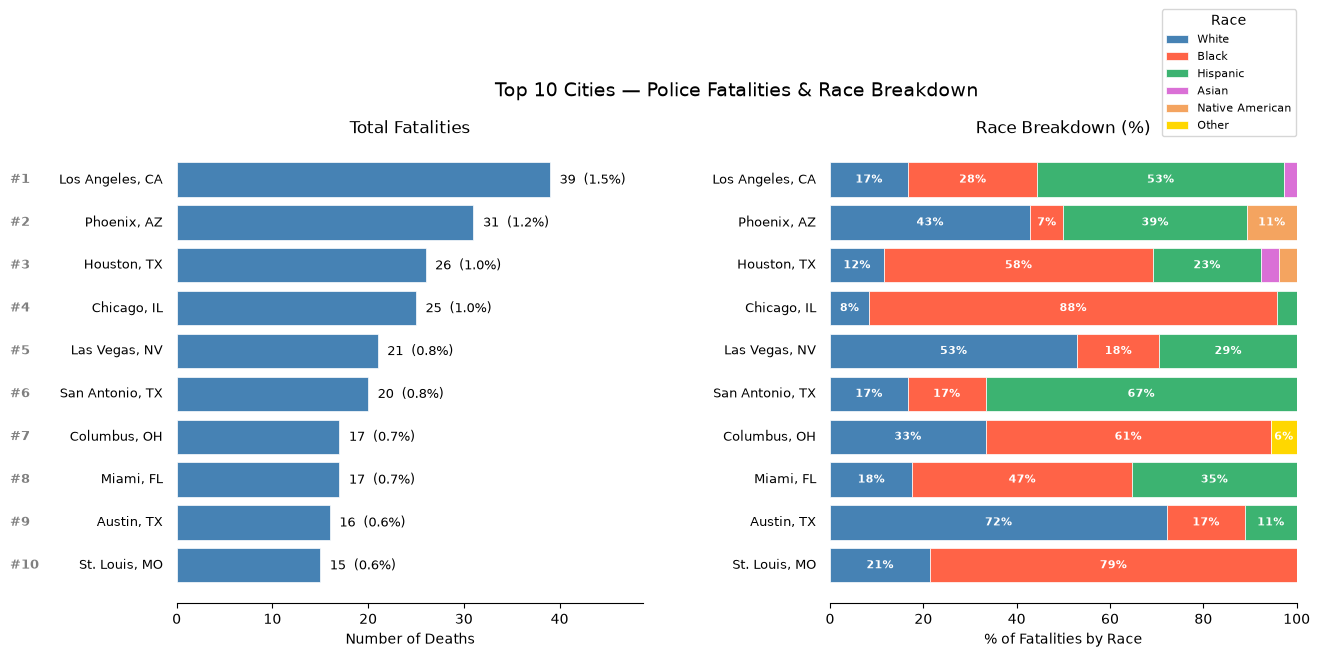

In [162]:
import matplotlib.pyplot as plt
import numpy as np

# ── Top 10 cities with state ───────────────────────────────────────────
df_cities = df_deaths_by_police.groupby(['city', 'state']).size().reset_index(name='count')
df_cities = df_cities.sort_values('count', ascending=False).head(10)
df_cities = df_cities.sort_values('count', ascending=True).reset_index(drop=True)
df_cities['rank'] = range(len(df_cities), 0, -1)

total = len(df_deaths_by_police)

# ── Race breakdown per city ────────────────────────────────────────────
race_labels = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other',
}

colors = {
    'W': 'steelblue',
    'B': 'tomato',
    'H': 'mediumseagreen',
    'A': 'orchid',
    'N': 'sandybrown',
    'O': 'gold',
}

df_race_city = df_deaths_by_police[
    df_deaths_by_police['city'].isin(df_cities['city']) &
    df_deaths_by_police['race'].isin(race_labels)
].groupby(['city', 'race']).size().reset_index(name='count')

# Pivot to get race columns per city
df_pivot = df_race_city.pivot(index='city', columns='race', values='count').fillna(0)
df_pivot = df_pivot.reindex(columns=race_labels.keys(), fill_value=0)

# Align pivot to city order
df_pivot = df_pivot.loc[df_cities['city']]
df_pivot_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 10 Cities — Police Fatalities & Race Breakdown', fontsize=14)

# ── Left: total count bar ──────────────────────────────────────────────
bars = ax1.barh(range(len(df_cities)), df_cities['count'],
                color='steelblue', edgecolor='white', linewidth=0.5)

for bar, (_, row) in zip(bars, df_cities.iterrows()):
    pct = (row['count'] / total) * 100
    ax1.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{row['count']:,}  ({pct:.1f}%)",
        va='center', fontsize=9
    )

for i, (_, row) in enumerate(df_cities.iterrows()):
    ax1.annotate(
        f"#{row['rank']}",
        xy=(0, i), xycoords=('axes fraction', 'data'),
        xytext=(-120, 0), textcoords='offset points',
        ha='left', va='center', fontsize=9,
        color='grey', fontweight='bold'
    )
    ax1.annotate(
        f"{row['city']}, {row['state']}",
        xy=(0, i), xycoords=('axes fraction', 'data'),
        xytext=(-10, 0), textcoords='offset points',
        ha='right', va='center', fontsize=9,
    )

ax1.set_yticks([])
ax1.set_xlabel('Number of Deaths')
ax1.set_xlim(0, df_cities['count'].max() * 1.25)
ax1.set_title('Total Fatalities')
ax1.spines[['top', 'right', 'left']].set_visible(False)

# ── Right: stacked % bar by race ───────────────────────────────────────
left = np.zeros(len(df_pivot_pct))
for race, label in race_labels.items():
    if race in df_pivot_pct.columns:
        values = df_pivot_pct[race].values
        ax2.barh(range(len(df_pivot_pct)), values, left=left,
                 color=colors[race], label=label,
                 edgecolor='white', linewidth=0.5)
        # Label if segment wide enough
        for i, (v, l) in enumerate(zip(values, left)):
            if v > 5:
                ax2.text(l + v / 2, i, f"{v:.0f}%",
                         ha='center', va='center', fontsize=8,
                         color='white', fontweight='bold')
        left += values

# City labels on right chart
for i, (_, row) in enumerate(df_cities.iterrows()):
    ax2.annotate(
        f"{row['city']}, {row['state']}",
        xy=(0, i), xycoords=('axes fraction', 'data'),
        xytext=(-10, 0), textcoords='offset points',
        ha='right', va='center', fontsize=9,
    )

ax2.set_yticks([])
ax2.set_xlim(0, 100)
ax2.set_xlabel('% of Fatalities by Race')
ax2.set_title('Race Breakdown (%)')
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.legend(
    loc='lower right', 
    fontsize=8, 
    title='Race',
    bbox_to_anchor=(1.01, 1)
    )

plt.subplots_adjust(left=0.15, wspace=0.4, right=0.85)
plt.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [165]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# ── Aggregate killings by state ────────────────────────────────────────
df_state_killings = df_deaths_by_police.groupby('state').size().reset_index(name='count')

# ── Aggregate poverty by state ─────────────────────────────────────────
# Extract state abbreviation from 'Geographic Area' (format: "AL - Alabama")
df_pct_people_below_poverty_level['state'] = df_pct_people_below_poverty_level['Geographic Area'].str.extract(r'^([A-Z]{2})')
df_state_poverty = df_pct_people_below_poverty_level.groupby('state')['poverty_rate'].mean().reset_index()

# ── Figure with two choropleth subplots ────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]],
    subplot_titles=['Police Killings by State', 'Poverty Rate by State (%)']
)

# ── Left: Police killings ──────────────────────────────────────────────
fig.add_trace(go.Choropleth(
    locations=df_state_killings['state'],
    z=df_state_killings['count'],
    locationmode='USA-states',
    colorscale='Reds',
    colorbar=dict(
        title='Deaths',
        x=0.46,
        len=0.8
    ),
    hovertemplate='<b>%{location}</b><br>Deaths: %{z}<extra></extra>',
    name='Killings'
), row=1, col=1)

# ── Right: Poverty rate ────────────────────────────────────────────────
fig.add_trace(go.Choropleth(
    locations=df_state_poverty['state'],
    z=df_state_poverty['poverty_rate'],
    locationmode='USA-states',
    colorscale='YlOrRd',
    colorbar=dict(
        title='Poverty %',
        x=1.0,
        len=0.8
    ),
    hovertemplate='<b>%{location}</b><br>Poverty Rate: %{z:.1f}%<extra></extra>',
    name='Poverty'
), row=1, col=2)

# ── Layout ─────────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='Police Killings vs Poverty Rate by State',
        x=0.5,
        font=dict(size=16)
    ),
    geo=dict(
        scope='usa',
        showlakes=True,
        lakecolor='lightblue',
    ),
    geo2=dict(
        scope='usa',
        showlakes=True,
        lakecolor='lightblue',
    ),
    height=500,
    margin=dict(t=60, l=0, r=0, b=0),
)

fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [172]:
df_deaths_by_police['year'] = df_deaths_by_police['date'].dt.year
df_deaths_by_police['month'] = df_deaths_by_police['date'].dt.month

df_monthly = df_deaths_by_police.groupby(['year', 'month']).size().reset_index(name='count')
df_monthly['year_month'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))

# print(df_monthly)

Trend slope : -0.038 deaths/month
Overall mean: 81.8 deaths/month
Highest month: Jul 2015 (104 deaths)
Lowest month : Jun 2015 (65 deaths)


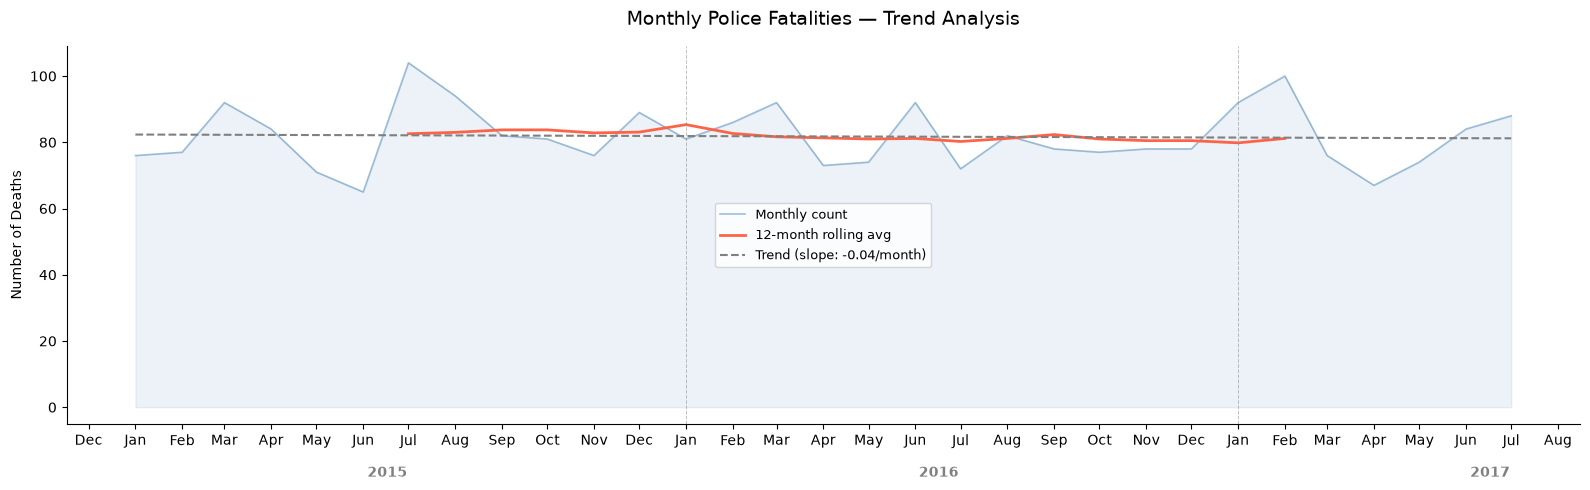

In [179]:
import numpy as np

# ── Add numeric index for trend line ──────────────────────────────────
df_monthly['x_idx'] = range(len(df_monthly))

# ── Fit linear trend ───────────────────────────────────────────────────
z = np.polyfit(df_monthly['x_idx'], df_monthly['count'], 1)
p = np.poly1d(z)
trend = p(df_monthly['x_idx'])

# ── 12-month rolling average ───────────────────────────────────────────
df_monthly['rolling_12'] = df_monthly['count'].rolling(window=12, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))

# Raw line
ax.plot(df_monthly['year_month'], df_monthly['count'],
        color='steelblue', linewidth=1.2, alpha=0.5, label='Monthly count')
ax.fill_between(df_monthly['year_month'], df_monthly['count'],
                alpha=0.1, color='steelblue')

# Rolling average
ax.plot(df_monthly['year_month'], df_monthly['rolling_12'],
        color='tomato', linewidth=2, label='12-month rolling avg')

# Linear trend
ax.plot(df_monthly['year_month'], trend,
        color='grey', linewidth=1.5, linestyle='--', label=f'Trend (slope: {z[0]:+.2f}/month)')

ax.set_title('Monthly Police Fatalities — Trend Analysis', fontsize=14, pad=15)
ax.set_xlabel('')
ax.set_ylabel('Number of Deaths')
ax.legend(fontsize=9)

# ── Month labels ───────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', rotation=0)
ax.spines[['top', 'right']].set_visible(False)

# ── Year labels ────────────────────────────────────────────────────────
years = df_monthly['year'].unique()
for year in sorted(years):
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end   = pd.Timestamp(f'{year}-12-01')
    year_mid   = year_start + (year_end - year_start) / 2
    if year != min(years):
        ax.axvline(x=year_start, color='grey', linewidth=0.7,
                   linestyle='--', alpha=0.5)
    ax.annotate(
        str(year),
        xy=(year_mid, 0),
        xycoords=('data', 'axes fraction'),
        xytext=(0, -30),
        textcoords='offset points',
        ha='center', va='top',
        fontsize=10, fontweight='bold', color='grey'
    )

# ── Print trend summary ────────────────────────────────────────────────
print(f"Trend slope : {z[0]:+.3f} deaths/month")
print(f"Overall mean: {df_monthly['count'].mean():.1f} deaths/month")
print(f"Highest month: {df_monthly.loc[df_monthly['count'].idxmax(), 'year_month'].strftime('%b %Y')} "
      f"({df_monthly['count'].max()} deaths)")
print(f"Lowest month : {df_monthly.loc[df_monthly['count'].idxmin(), 'year_month'].strftime('%b %Y')} "
      f"({df_monthly['count'].min()} deaths)")

plt.tight_layout()
plt.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).

In [ ]:
df_deaths_by_police.tail(5)